In [62]:
import pandas as pd
import numpy as np
from huggingface_hub import login
from dotenv import load_dotenv
import json
from transformers import AutoTokenizer
import sys; sys.path.insert(0, '..')
from datatypes.jd_data_type import JobDescription
from utils.jd_util import JobDescriptionUtil
from utils.constants import Constants
from utils.jd_model import JobDescriptionModel
from sklearn.model_selection import train_test_split
from datasets import DatasetDict, Dataset
import os
from utils.ollama_util import Ollama
from tqdm import tqdm

## Login

In [42]:
# load_dotenv(override=True)
# HF_TOKEN = os.getenv('HF_TOKEN')
# login(token=HF_TOKEN)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


## Load Dataset

In [3]:
path_to_dataset = "../datasets/job_descriptions.csv" # Created job description from Claude with reference to LinkedIn.

In [4]:
df = pd.read_csv(path_to_dataset)
df.head()

,job_description,structured_json
0,Role Overview\na fintech company is seeking a ...,"{""job_summary"": ""a fintech company is seeking ..."
1,The Role\nJoin a remote-first company as a Lea...,"{""job_summary"": ""Join a remote-first company a..."
2,Who We're Looking For\nWe're hiring a Lead MLO...,"{""job_summary"": ""We're hiring a Lead MLOps Eng..."
3,Job Summary\nWe're hiring a Senior Backend Eng...,"{""job_summary"": ""We're hiring a Senior Backend..."
4,Description\nWe are looking for a Java Develop...,"{""job_summary"": ""We are looking for a Java Dev..."


In [5]:
sample_idx = 0

In [6]:
print(df['job_description'].iloc[sample_idx])

Role Overview
a fintech company is seeking a Mid-level React Developer to help us with building modern, component-based frontend applications. This is a hands-on role for someone who thrives in a fast-paced, collaborative environment. This is a mid-level position for someone ready to take ownership of features and deliver independently.
Nice-to-Haves:
* Storybook
* Tailwind CSS
* Performance tuning
* Testing libraries
* Next.js
* Experience contributing to open-source projects
Must Have:
* REST / GraphQL integration
* React
* Component-driven development
* State management
* JavaScript / TypeScript
* Solid computer science fundamentals, formal degree or self-taught
* Strong understanding of software engineering fundamentals
The Right Mindset:
* Ability to work independently and collaboratively
* Genuine curiosity and eagerness to learn new technologies
* Strong ownership and accountability
* Comfort working in a fast-paced, ambiguous environment
* Excellent problem-solving and analytic

In [7]:
print(json.dumps((json.loads(df["structured_json"].iloc[sample_idx])), indent=4))

{
    "job_summary": "a fintech company is seeking a Mid-level React Developer to help us with building modern, component-based frontend applications. This is a hands-on role for someone who thrives in a fast-paced, collaborative environment. This is a mid-level position for someone ready to take ownership of features and deliver independently.",
    "role_description": [
        "Write clean, maintainable, and well-tested code",
        "Design, develop, and maintain building modern, component-based frontend applications",
        "Collaborate with product, design, and engineering teams to deliver high-quality features",
        "Review code and provide constructive feedback to peers",
        "Translate business requirements into scalable technical solutions"
    ],
    "required_skills": [
        "REST / GraphQL integration",
        "React",
        "Component-driven development",
        "State management",
        "JavaScript / TypeScript",
        "Strong understanding of softw

In [8]:
jd_texts = [text for text in df["job_description"]]

## Data Analysis

In [9]:
tokenizer = AutoTokenizer.from_pretrained(Constants.EXTRACTION_BASE_MODEL_NAME)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   job_description  500 non-null    str  
 1   structured_json  500 non-null    str  
dtypes: str(2)
memory usage: 1.6 MB


In [11]:
jd_jsons = [JobDescription.model_validate_json(jd) for jd in df["structured_json"]]
print(f"All Job description are valid: {all(jd_jsons)}" )

All Job description are valid: True


In [12]:
# Checking for how many inferred texts (from the JD json) are not found in the JD text...
all_inferred_texts = []
for idx, (jd, text) in enumerate(zip(jd_jsons, jd_texts)):
    inferred_texts = JobDescriptionUtil.get_inferred_texts_from_jd(jd, text)
    all_inferred_texts.extend([{"index": idx, "text_from_json": value} for value in inferred_texts])

print(f"Total inferred (not found in JD text): {len(all_inferred_texts)}")
for item in all_inferred_texts:
    print(item)

Total inferred (not found in JD text): 0


In [13]:
# Checking how many JD have non numeric min and max experience years
non_numeric_max_exp = []
non_numeric_min_exp = []
for idx, jd in enumerate(jd_jsons):
    is_min_exp_number = JobDescriptionUtil.min_exp_is_number_or_none(jd)
    is_max_exp_number = JobDescriptionUtil.max_exp_is_number_or_none(jd)
    if not is_min_exp_number:
        non_numeric_min_exp.append(idx)
    if not is_max_exp_number:
        non_numeric_max_exp.append(idx)

print(f"Total number of non numeric minimum experience: {len(non_numeric_min_exp)}")
if len(non_numeric_min_exp):
    print(non_numeric_min_exp)
print(f"Total number of non numeric maximum experience: {len(non_numeric_max_exp)}")
if len(non_numeric_max_exp):
    print(non_numeric_max_exp)

Total number of non numeric minimum experience: 0
Total number of non numeric maximum experience: 0


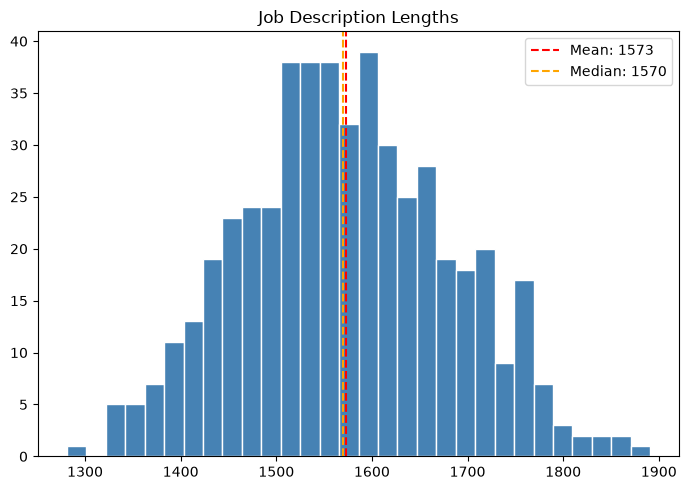

Min:      1281
Max:      1891
Mean:     1573
Median:   1570
Std:       109


In [14]:
# Checking the character counts of job descriptions
jd_lengths = [len(jd_text) for jd_text in df["job_description"]]
JobDescriptionUtil.plot_jd_data(jd_lengths, title="Job Description Lengths")

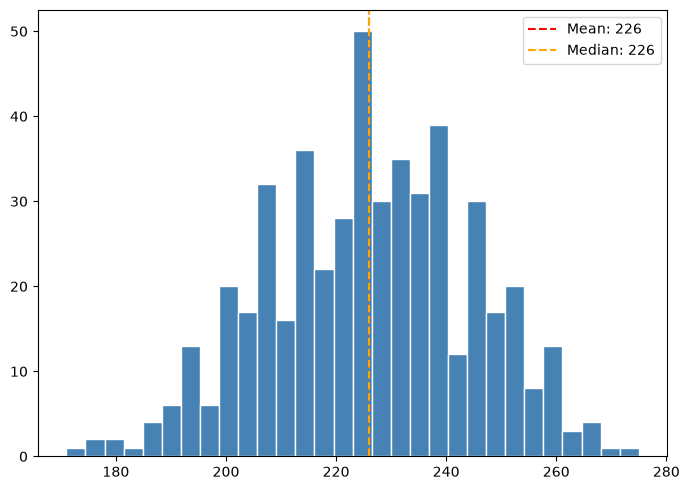

Min:       171
Max:       275
Mean:      226
Median:    226
Std:        19


In [15]:
# Checking the word counts of JDs
jd_word_counts = [len(text.split()) for text in df["job_description"]]
JobDescriptionUtil.plot_jd_data(jd_word_counts)

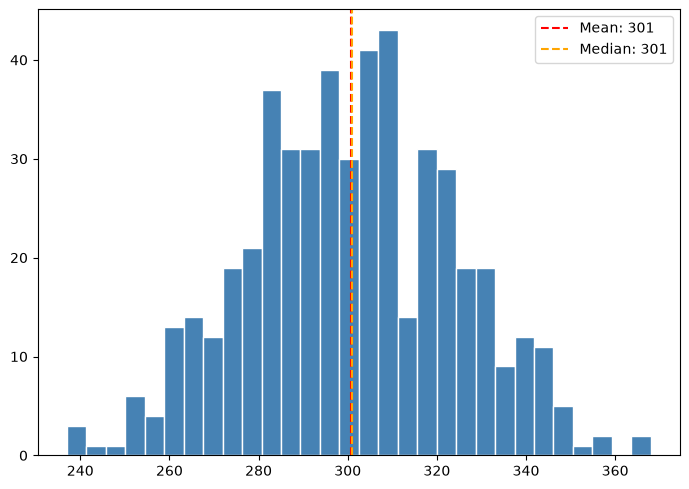

Min:       237
Max:       368
Mean:      301
Median:    301
Std:        23


In [16]:
# Checking the token counts in all JD texts
jd_text_token_lengths = [len(tokenizer.encode(text)) for text in df["job_description"]]
JobDescriptionUtil.plot_jd_data(jd_text_token_lengths)

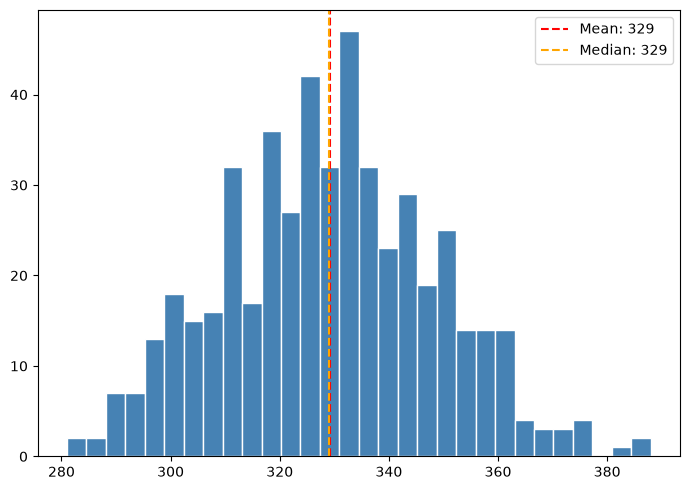

Min:       281
Max:       388
Mean:      329
Median:    329
Std:        19


In [17]:
# Checking token counts in the job description json format
structured_json_token_length = [len(tokenizer.encode(text)) for text in df["structured_json"]]
JobDescriptionUtil.plot_jd_data(structured_json_token_length)

In [18]:
# Checking the length of System prompt
print(f"Length of system prompt: {len(tokenizer.encode(Constants.JD_EXTRACTION_SYSTEM_PROMPT))} tokens")

Length of system prompt: 205 tokens


In [19]:
# Checking the length of tokens in user prompt
print(f"Length of user prompt: {len(tokenizer.encode(Constants.JD_EXTRACTION_USER_PROMPT_TEMPLATE))} tokens")

Length of user prompt: 16 tokens


#### Analysis Results:
- Total number of rows: 500
- Total number of JSONs which are not proper: 0
- Total inferred (not found in job description text): 0
- Total number of non-numeric maximum experience years: 0
- Total number of non-numeric minimum experience years: 0
- Maximum characters in job description text: 1891
- Maximum words in job description text: 275
- Maximum token size in job description text: 368
- Maximum token size in job description json: 388
- Number of tokens in system prompt: 205
- Number of tokens in user prompt: 16

## Creatng train, validation and test datasets

In [20]:
model = JobDescriptionModel(Constants.JD_EXTRACTION_FT_OLLAMA_ENDPOINT)

In [21]:
def make_message(row):
    return model.make_prompt_with_assistant(row["job_description"], row["structured_json"])

In [22]:
df["messages"] = df.apply(make_message, axis=1)
final_df = df[['messages']]
final_df

,messages
0,"[{'role': 'system', 'content': 'You are a Job ..."
1,"[{'role': 'system', 'content': 'You are a Job ..."
2,"[{'role': 'system', 'content': 'You are a Job ..."
3,"[{'role': 'system', 'content': 'You are a Job ..."
4,"[{'role': 'system', 'content': 'You are a Job ..."
...,...
495,"[{'role': 'system', 'content': 'You are a Job ..."
496,"[{'role': 'system', 'content': 'You are a Job ..."
497,"[{'role': 'system', 'content': 'You are a Job ..."
498,"[{'role': 'system', 'content': 'You are a Job ..."


In [30]:
train_df, temp_df = train_test_split(final_df, random_state=42, test_size=0.14)
train_df.info()

<class 'pandas.DataFrame'>
Index: 430 entries, 352 to 102
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   messages  430 non-null    object
dtypes: object(1)
memory usage: 6.7+ KB


In [31]:
valid_df, test_df = train_test_split(temp_df, random_state=42, train_size=0.5)
valid_df.info()

<class 'pandas.DataFrame'>
Index: 35 entries, 72 to 182
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   messages  35 non-null     object
dtypes: object(1)
memory usage: 560.0+ bytes


## Saving dataset as hugging face dataset

In [32]:
dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df, preserve_index=False),
    "validation": Dataset.from_pandas(valid_df, preserve_index=False),
    "test": Dataset.from_pandas(test_df, preserve_index=False)
})
dataset

DatasetDict({
    train: Dataset({
        features: ['messages'],
        num_rows: 430
    })
    validation: Dataset({
        features: ['messages'],
        num_rows: 35
    })
    test: Dataset({
        features: ['messages'],
        num_rows: 35
    })
})

In [43]:
# Save dataset in huggingface hub
# dataset.push_to_hub(Constants.JD_EXTRACTION_DATASET_NAME)

Setting num_proc from 1 back to 1 for the train split to disable multiprocessing as it only contains one shard.


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

...

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/datasets/sawarni99/jd-to-json-dataset/commit/e2c319f653d5b349473387df3ddfb53601b96d8d', commit_message='Upload dataset', commit_description='', oid='e2c319f653d5b349473387df3ddfb53601b96d8d', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/sawarni99/jd-to-json-dataset', endpoint='https://huggingface.co', repo_type='dataset', repo_id='sawarni99/jd-to-json-dataset'), pr_revision=None, pr_num=None)

## Training

#### Training is done on Kaggle
[Link](https://www.kaggle.com/code/sawarni99/job-description-extraction-training-unsloth) to the colab and the model is pushed to hub.

- Base model used for finetuning: Llama-3.2-3B-Instruct
- Used unsloth FastLanguageModel for fine tuning.
- Used quantization of 4-bit with 16 rank LoRA adapter on attention layers.

Training Loss: 0.128000
<br>
Validation Loss: 0.129740
<br>
Training reports: [wandb](https://wandb.ai/sawarni/huggingface/runs/2nqjd2t8?nw=nwusersawarni99)

## Inference

In [46]:
# Ollama(Constants.JD_EXTRACTION_FT_OLLAMA_ENDPOINT).delete()

In [86]:
# A sample from linkedin jobs
sample_text = '''About Outmarket

Outmarket is the AI platform for insurance, trusted by more than 250 brokerages to run the work their business depends on. Commercial insurance still runs on dense documents and slow, manual workflows, and that is exactly what we automate: quote comparisons, coverage gap and tower analysis, policy review, and proposal generation, all grounded in our customers’ own data and source-cited so teams can trust the output.

The impact is concrete. Teams save 12 to 15 hours per person every week, cut errors by roughly 65 percent, and win more business, all on infrastructure that is SOC 2 Type II certified, single-tenant, and never used to train AI models. We are an AI-first company in both what we build and how we work, shipping quickly and in close partnership with the agencies that rely on us.

What You’ll Get

A high-impact role with ownership from day one. 
Competitive compensation and meaningful equity. 
Direct collaboration with founders and real users. 
Remote-first flexibility. 
The opportunity to help build an AI-native product from the ground up. 

About The Role

We are hiring a Front End AI Engineer to build intuitive, high-performance product experiences that bring complex AI workflows to life. We want someone who cares how the product behaves, how customers use it, and how interface decisions affect trust in AI.

WHY THIS ROLE

Build the user-facing layer of AI-powered workflows used by real customers. 
Define fast, intuitive interfaces in a product with meaningful workflow complexity. 
Shape a design system and frontend foundation that scales with the company. 

What You’ll Do

Collaborate with design and backend teams to ship seamless experiences in React from Figma designs. 
Build and maintain reusable UI components and systems that scale across customers. 
Implement frontend features that interact with AI services such as document review, entity extraction, and quote comparison. 
Rapidly prototype and iterate based on user feedback and evolving priorities. 

What We’re Looking For

2+ years building frontend applications with React. 
Proficiency with design tools and handoff workflows, especially Figma. 
Strong product sense and the ability to translate complex workflows into clean UX. 
Familiarity with REST or GraphQL APIs and state management patterns. 
Good judgment about where polish matters and where speed matters. 

BONUS IF YOU HAVE

Experience with data-rich or document-heavy interfaces. 
Experience building LLM-integrated product experiences. 
Modern dev-tool fluency (e.g., Cursor).'''

In [87]:

response = model.generate(sample_text)
response

'{"job_summary": "Build the user-facing layer of AI-powered workflows used by real customers. Define fast, intuitive interfaces in a product with meaningful workflow complexity. Shape a design system and frontend foundation that scales with the company.", "role_description": ["Collaborate with design and backend teams to ship seamless experiences in React from Figma designs", "Build and maintain reusable UI components and systems that scale across customers", "Implement frontend features that interact with AI services such as document review, entity extraction, and quote comparison", "Rapidly prototype and iterate based on user feedback and evolving priorities"], "required_skills": ["2+ years building frontend applications with React", "Proficiency with design tools and handoff workflows, especially Figma", "Strong product sense and the ability to translate complex workflows into clean UX", "Familiarity with REST or GraphQL APIs and state management patterns", "Good judgment about wher

In [88]:
sample_jd = JobDescriptionUtil.create(response)
JobDescriptionUtil.format(sample_jd)

{
    "job_summary": "Build the user-facing layer of AI-powered workflows used by real customers. Define fast, intuitive interfaces in a product with meaningful workflow complexity. Shape a design system and frontend foundation that scales with the company.",
    "role_description": [
        "Collaborate with design and backend teams to ship seamless experiences in React from Figma designs",
        "Build and maintain reusable UI components and systems that scale across customers",
        "Implement frontend features that interact with AI services such as document review, entity extraction, and quote comparison",
        "Rapidly prototype and iterate based on user feedback and evolving priorities"
    ],
    "required_skills": [
        "2+ years building frontend applications with React",
        "Proficiency with design tools and handoff workflows, especially Figma",
        "Strong product sense and the ability to translate complex workflows into clean UX",
        "Familiarity 

In [76]:
print(response)

{
  "job_summary": "",
  "role_description": [
    "Design, develop, and maintain responsive, scalable web user interfaces using React.js and TypeScript."
  ],
  "required_skills": [
    "5+ years of professional experience in frontend development with a strong focus on React.js.",
    "Strong proficiency in JavaScript (ES6+), TypeScript, HTML5, and CSS3.",
    "Deep understanding of React fundamentals including Functional Components, Hooks, Component Lifecycle, State Management, Context API, Strong experience with Redux for application state management."
  ],
  "general_skills": [
    "Collaborate closely with UX/UI designers, architects, product owners, project managers, backend engineers, and QA teams.",
    "Translate wireframes, mockups, and design prototypes into high-quality production-ready code.",
    "Contribute to backend API development and integration using Python and Django framework.",
    "Design and consume RESTful APIs for seamless frontend-backend integration."
  ],


## Evaluation

In [58]:
tests = dataset["test"]
tests

Dataset({
    features: ['messages'],
    num_rows: 35
})

In [ ]:
def infer_and_evaluate(min, max, output_file=None):
    sample_test = tests.select(range(min, max))
    responses = []
    
    for test in tqdm(sample_test):
        messages = test["messages"]
        prediction = model.generate(messages[0:2])
        reference = messages[2]["content"]
        responses.append({
            "prediction": prediction,
            "reference": reference
        })

    predictions = [obj["prediction"] for obj in responses]
    references = [obj["reference"] for obj in responses]

    return model.evaluate(predictions=predictions, references=references, output_file=output_file)

In [80]:
infer_and_evaluate(10, 20)

100%|██████████| 10/10 [01:08<00:00,  6.87s/it]


{'total_tests': 10,
 'rouge': {'rouge1': np.float64(0.9997885835095136),
  'rouge2': np.float64(0.9993630573248409),
  'rougeL': np.float64(0.9997885835095136),
  'rougeLsum': np.float64(0.9997885835095136)},
 'exact_match': {'exact_match': np.float64(0.9)},
 'valid_json': {'valid_json_count': 10,
  'valid_json_score': 1.0,
  'invalid_json_idx': []},
 'valid_exp_yrs': {'number_non_numeric_min_exp': 0,
  'non_numeric_min_exp_idx': [],
  'number_non_numeric_max_exp': 0,
  'non_numeric_max_exp_idx': []}}

In [68]:
# infer_and_evaluate(0, 10, "../evals/jd_extraction/jd_extraction_test_0_10.json")
# infer_and_evaluate(10, 20, "../evals/jd_extraction/jd_extraction_test_10_20.json")
# infer_and_evaluate(20, 30, "../evals/jd_extraction/jd_extraction_test_20_30.json")
infer_and_evaluate(30, 35, "../evals/jd_extraction/jd_extraction_test_30_35.json")

100%|██████████| 5/5 [00:35<00:00,  7.05s/it]


{'total_tests': 5,
 'rouge': {'rouge1': np.float64(0.9990936819172113),
  'rouge2': np.float64(0.997268649999224),
  'rougeL': np.float64(0.9990936819172113),
  'rougeLsum': np.float64(0.9990936819172113)},
 'exact_match': {'exact_match': np.float64(0.6)},
 'valid_json': {'valid_json_count': 5,
  'valid_json_score': 1.0,
  'invalid_json_idx': []},
 'valid_exp_yrs': {'number_non_numeric_min_exp': 0,
  'non_numeric_min_exp_idx': [],
  'number_non_numeric_max_exp': 0,
  'non_numeric_max_exp_idx': []}}